# 05 - Feature Reduction
**DNA Gene Mapping Project - ML Phase V5 - Feature Selection**  
**Author:** Sharique Mohammad  
**Date:** February 2026   

## Purpose
Combine all upstream results (quality, correlation, leakage) into the final
approved feature list for each use case. This is the single source of truth
consumed by all training notebooks.

## Logic
For each use case, a feature is APPROVED if:
  - Not an ID/metadata column (from 02)
  - Not high-missing or zero-variance (from 02)
  - Not flagged as leakage (from 04)
  - Not the weaker half of a high-correlation pair (from 03)

## Output
`data/feature_lists/`  (one CSV per use case)
  uc01_clinical_features.csv
  uc02_disease_features.csv
  ... through ...
  uc15_cancer_molecular_features.csv

`data/feature_lists/feature_selection_summary.csv`
  - use_case, table, target, final_feature_count, removed_quality,
    removed_leakage, removed_correlation

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import os
from pathlib import Path
from dotenv import load_dotenv
import warnings
warnings.filterwarnings('ignore')

load_dotenv()

PROJECT_ROOT = Path().absolute().parent.parent
FS_DIR       = PROJECT_ROOT / 'data' / 'feature_selection'
FS_DIR.mkdir(parents=True, exist_ok=True)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Setup complete")
print(f"Feature selection dir: {FS_DIR}")

Setup complete
Feature selection dir: C:\Users\Sharique\Desktop\Self_Project\GitHub_Project\genomic-variant-data-science-pipeline\data\feature_selection


## 2. Load All Upstream Results

In [2]:
quality_df  = pd.read_csv(FS_DIR / '02_feature_quality.csv')
corr_df     = pd.read_csv(FS_DIR / '03_high_correlation_pairs.csv') if (FS_DIR / '03_high_correlation_pairs.csv').exists() else pd.DataFrame(columns=['use_case','drop_feature'])
leakage_df  = pd.read_csv(FS_DIR / '04_leakage_flags.csv')
target_df   = pd.read_csv(FS_DIR / '01_target_definitions.csv')

print(f"Quality rows    : {len(quality_df)}")
print(f"Corr drop pairs : {len(corr_df)}")
print(f"Leakage flags   : {len(leakage_df)}")
print(f"Target defs     : {len(target_df)}")

Quality rows    : 804
Corr drop pairs : 147
Leakage flags   : 102
Target defs     : 15


## 3. Feature Reduction Loop

In [3]:
FEATURE_DIR = PROJECT_ROOT / 'data' / 'feature_lists'
FEATURE_DIR.mkdir(parents=True, exist_ok=True)

UC_META = [
    ('UC01','clinical_ml_features',               'target_is_pathogenic',                 'uc01_clinical'),
    ('UC02','disease_ml_features',                'is_pathogenic',                        'uc02_disease'),
    ('UC03','pharmacogene_ml_features',           'is_pathogenic',                        'uc03_pharmacogene'),
    ('UC04','variant_impact_ml_features',         'is_high_impact',                       'uc04_variant_impact'),
    ('UC05','structural_variant_ml_features',     'sv_classification',                    'uc05_structural_variant'),
    ('UC06','variant_drug_response_ml_features',  'is_actionable_pharmacogene_variant',   'uc06_drug_response_variant'),
    ('UC07','variant_cancer_ml_features',         'is_driver_candidate',                  'uc07_cancer_variant'),
    ('UC08','variant_population_ml_features',     'is_carrier_screening_candidate',       'uc08_carrier_screening'),
    ('UC09','population_frequency_ml_features',   'is_clinically_actionable_rare_variant','uc09_population_frequency'),
    ('UC10','gene_pharmacogene_ml_features',      'is_high_priority_pharmacogene',        'uc10_gene_pharmacogene'),
    ('UC11','gene_expression_ml_features',        'is_clinically_relevant_expression',    'uc11_gene_expression'),
    ('UC12','gene_protein_family_ml_features',    'is_high_value_protein_family',         'uc12_protein_family'),
    ('UC13','gene_test_availability_ml_features', 'is_high_priority_test_gene',           'uc13_gene_test'),
    ('UC14','transcript_expression_ml_features',  'is_clinically_relevant_expression',    'uc14_expression_simple'),
    ('UC15','cancer_variant_ml_features',         'gene_cancer_role',                     'uc15_cancer_molecular'),
]

summary_rows = []

for uc, table, target, fname in UC_META:
    # Step 1: start with quality-passed non-ID columns
    passed_quality = quality_df[
        (quality_df['use_case'] == uc) &
        (quality_df['keep'] == True)
    ]['column'].tolist()

    # Step 2: remove leakage-flagged columns
    leakage_drop = set(
        leakage_df[leakage_df['use_case'] == uc]['column'].tolist()
    )
    after_leakage = [c for c in passed_quality if c not in leakage_drop]

    # Step 3: remove high-correlation drops
    corr_drop = set(
        corr_df[corr_df['use_case'] == uc]['drop_feature'].tolist()
    ) if len(corr_df) > 0 else set()
    final_features = [c for c in after_leakage if c not in corr_drop]

    # Save feature list
    out_path = FEATURE_DIR / f'{fname}_features.csv'
    pd.DataFrame({
        'feature': final_features,
        'use_case': uc,
        'table': table
    }).to_csv(out_path, index=False)

    # Compute counts
    n_quality   = len(passed_quality)
    n_leakage   = len([c for c in passed_quality if c in leakage_drop])
    n_corr      = len([c for c in after_leakage if c in corr_drop])
    n_final     = len(final_features)

    # Get total_rows and smote_needed from target_df
    tgt_row = target_df[target_df['use_case'] == uc]
    total_rows  = int(tgt_row['total_rows'].iloc[0]) if len(tgt_row) > 0 else 0
    smote       = bool(tgt_row['smote_needed'].iloc[0]) if len(tgt_row) > 0 else False
    cv_req      = bool(tgt_row['cv_required'].iloc[0]) if len(tgt_row) > 0 else False

    print(f"{uc:<5} {fname:<35} quality={n_quality:>3}  -leakage={n_leakage:>2}  -corr={n_corr:>2}  FINAL={n_final:>3}  rows={total_rows:,}")

    summary_rows.append({
        'use_case': uc, 'table': table, 'target': target,
        'output_file': f'{fname}_features.csv',
        'after_quality_filter': n_quality,
        'removed_leakage': n_leakage,
        'removed_correlation': n_corr,
        'final_feature_count': n_final,
        'total_rows': total_rows,
        'smote_needed': smote,
        'cv_required': cv_req
    })

UC01  uc01_clinical                       quality= 78  -leakage= 6  -corr=16  FINAL= 56  rows=416,264
UC02  uc02_disease                        quality= 51  -leakage= 8  -corr=14  FINAL= 29  rows=418,099
UC03  uc03_pharmacogene                   quality= 64  -leakage= 8  -corr=11  FINAL= 45  rows=417,123
UC04  uc04_variant_impact                 quality= 86  -leakage=16  -corr=14  FINAL= 56  rows=413,049
UC05  uc05_structural_variant             quality= 24  -leakage= 4  -corr= 7  FINAL= 13  rows=216,951
UC06  uc06_drug_response_variant          quality= 50  -leakage= 9  -corr= 2  FINAL= 39  rows=414,628
UC07  uc07_cancer_variant                 quality= 37  -leakage= 5  -corr= 7  FINAL= 25  rows=310,623
UC08  uc08_carrier_screening              quality= 42  -leakage=10  -corr= 5  FINAL= 27  rows=46,339
UC09  uc09_population_frequency           quality= 20  -leakage= 5  -corr= 2  FINAL= 13  rows=46,339
UC10  uc10_gene_pharmacogene              quality= 52  -leakage=10  -corr=16  FINAL=

## 4. Save Summary

In [4]:
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(FEATURE_DIR / 'feature_selection_summary.csv', index=False)
print("Saved: feature_selection_summary.csv")
print()
print(summary_df[['use_case','table','final_feature_count',
                   'removed_leakage','removed_correlation',
                   'smote_needed','cv_required']].to_string(index=False))

Saved: feature_selection_summary.csv

use_case                              table  final_feature_count  removed_leakage  removed_correlation  smote_needed  cv_required
    UC01               clinical_ml_features                   56                6                   16          True        False
    UC02                disease_ml_features                   29                8                   14          True        False
    UC03           pharmacogene_ml_features                   45                8                   11          True        False
    UC04         variant_impact_ml_features                   56               16                   14          True        False
    UC05     structural_variant_ml_features                   13                4                    7         False        False
    UC06  variant_drug_response_ml_features                   39                9                    2         False        False
    UC07         variant_cancer_ml_features         

## 5. Visualize Final Feature Counts

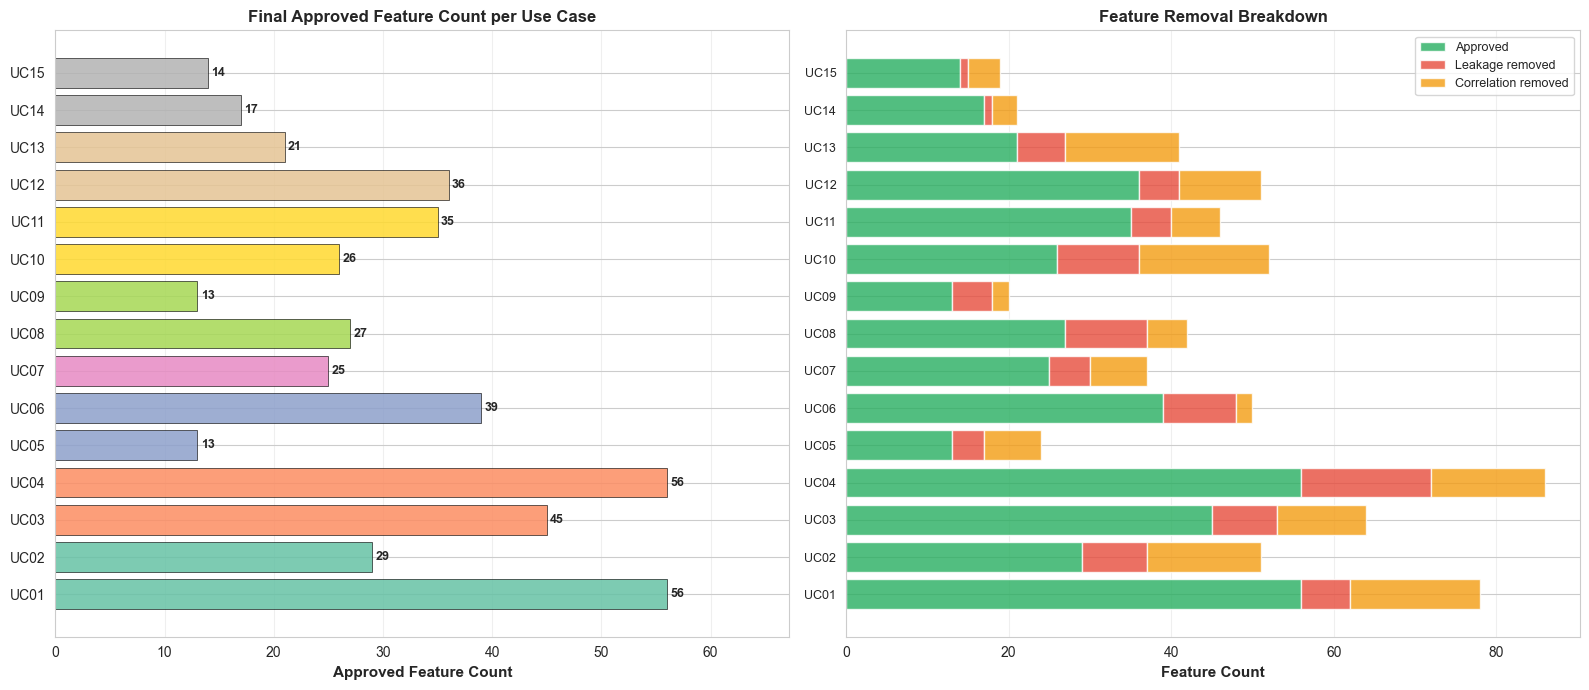

Saved: feature_reduction_summary.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Feature count bar
colors = plt.cm.Set2(np.linspace(0, 1, len(summary_df)))
bars = axes[0].barh(summary_df['use_case'], summary_df['final_feature_count'],
                     color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, summary_df['final_feature_count']):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2.,
                 str(val), va='center', fontsize=9, fontweight='bold')
axes[0].set_xlabel('Approved Feature Count', fontsize=11, fontweight='bold')
axes[0].set_title('Final Approved Feature Count per Use Case', fontsize=12, fontweight='bold')
axes[0].set_xlim(0, summary_df['final_feature_count'].max() * 1.2)
axes[0].grid(axis='x', alpha=0.3)

# Removal breakdown stacked bar
x    = range(len(summary_df))
rem_l = summary_df['removed_leakage'].values
rem_c = summary_df['removed_correlation'].values
rem_q = (summary_df['after_quality_filter'] - summary_df['after_quality_filter']).values  # zero (quality already applied)

axes[1].barh(x, summary_df['final_feature_count'].values, color='#27ae60', alpha=0.8, label='Approved')
axes[1].barh(x, rem_l, left=summary_df['final_feature_count'].values, color='#e74c3c', alpha=0.8, label='Leakage removed')
axes[1].barh(x, rem_c, left=summary_df['final_feature_count'].values + rem_l, color='#f39c12', alpha=0.8, label='Correlation removed')
axes[1].set_yticks(list(x))
axes[1].set_yticklabels(summary_df['use_case'].tolist(), fontsize=9)
axes[1].set_xlabel('Feature Count', fontsize=11, fontweight='bold')
axes[1].set_title('Feature Removal Breakdown', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(FEATURE_DIR / 'feature_reduction_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_reduction_summary.png")

## 6. Print All Approved Feature Lists

In [6]:
print("APPROVED FEATURE LISTS")
print("=" * 65)
for uc, table, target, fname in UC_META:
    fpath    = FEATURE_DIR / f'{fname}_features.csv'
    feat_df  = pd.read_csv(fpath)
    features = feat_df['feature'].tolist()
    print(f"\n{uc} - {fname}")
    print(f"  Table  : {table}")
    print(f"  Target : {target}")
    print(f"  Count  : {len(features)}")
    print(f"  List   : {features}")

APPROVED FEATURE LISTS

UC01 - uc01_clinical
  Table  : clinical_ml_features
  Target : target_is_pathogenic
  Count  : 56
  List   : ['gene_is_validated', 'gene_is_well_characterized', 'is_pharmacogene', 'druggability_score', 'target_is_benign', 'target_is_vus', 'clinical_sig_is_uncertain', 'review_quality_score', 'has_strong_evidence', 'mutation_severity_score', 'pathogenicity_score', 'combined_pathogenicity_risk', 'is_coding_variant', 'is_regulatory_variant', 'is_missense_variant', 'is_frameshift_variant', 'is_nonsense_variant', 'phylop_score', 'conservation_level', 'is_likely_deleterious', 'is_high_impact', 'is_very_high_impact', 'is_domain_affecting', 'is_loss_of_function', 'has_conservation_data', 'inheritance_pattern', 'is_mitochondrial_variant', 'is_y_linked_variant', 'is_autosomal_variant', 'gene_benign_count', 'gene_pathogenic_ratio', 'gene_benign_ratio', 'gene_vus_ratio', 'gene_mutation_burden', 'gene_is_pathogenic_enriched', 'gene_is_benign_enriched', 'gene_is_vus_enriched'

## 7. Final Summary

In [7]:
print()
print("=" * 65)
print("FEATURE SELECTION PHASE COMPLETE")
print("=" * 65)
print(f"Feature lists saved to : {FEATURE_DIR}")
print(f"Summary saved to       : {FEATURE_DIR / 'feature_selection_summary.csv'}")
print()
print(f"Total use cases        : {len(summary_df)}")
print(f"SMOTE needed           : {summary_df[summary_df['smote_needed']==True]['use_case'].tolist()}")
print(f"CV required            : {summary_df[summary_df['cv_required']==True]['use_case'].tolist()}")
print()
print("Feature count range:")
print(f"  Min : {summary_df['final_feature_count'].min()} ({summary_df.loc[summary_df['final_feature_count'].idxmin(),'use_case']})")
print(f"  Max : {summary_df['final_feature_count'].max()} ({summary_df.loc[summary_df['final_feature_count'].idxmax(),'use_case']})")
print(f"  Avg : {summary_df['final_feature_count'].mean():.1f}")
print()
print("Next: 03_modeling/ -> 10_train_variant_pathogenicity_models.ipynb")


FEATURE SELECTION PHASE COMPLETE
Feature lists saved to : C:\Users\Sharique\Desktop\Self_Project\GitHub_Project\genomic-variant-data-science-pipeline\data\feature_lists
Summary saved to       : C:\Users\Sharique\Desktop\Self_Project\GitHub_Project\genomic-variant-data-science-pipeline\data\feature_lists\feature_selection_summary.csv

Total use cases        : 15
SMOTE needed           : ['UC01', 'UC02', 'UC03', 'UC04', 'UC07', 'UC08', 'UC09', 'UC10', 'UC11', 'UC12', 'UC13', 'UC14', 'UC15']
CV required            : ['UC10']

Feature count range:
  Min : 13 (UC05)
  Max : 56 (UC01)
  Avg : 30.1

Next: 03_modeling/ -> 10_train_variant_pathogenicity_models.ipynb
